In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [75]:
df = pd.read_parquet("../data/02_cleaned_merged/merged_and_cleaned.parquet")
rfm = pd.read_csv("../data/02_cleaned_merged/rfm.csv")
cohort = pd.read_csv("../data/02_cleaned_merged/cohort.csv")
cohort_matrix = pd.read_pickle("../data/02_cleaned_merged/cohort_matrix.pkl")

In [76]:
churned_days = 90 # this is considered as a safe number to find the customers who have churned
df.head(1)
rfm.head(1)

,customer_unique_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,Segment
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.9,4,1,4,414,Big_Spenders


In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100756 entries, 0 to 103886
Data columns (total 18 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   customer_id                    100756 non-null  object        
 1   customer_unique_id             100756 non-null  object        
 2   customer_zip_code_prefix       100756 non-null  int64         
 3   customer_city                  100756 non-null  object        
 4   customer_state                 100756 non-null  object        
 5   order_id                       100756 non-null  object        
 6   order_status                   100756 non-null  object        
 7   order_purchase_timestamp       100756 non-null  datetime64[ns]
 8   order_approved_at              100742 non-null  datetime64[ns]
 9   order_delivered_carrier_date   100754 non-null  datetime64[ns]
 10  order_delivered_customer_date  100748 non-null  datetime64[ns]
 11  order

In [78]:
cols = ['order_month','cohort_month']
df[cols] = df[cols].astype('datetime64[ns]')

In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100756 entries, 0 to 103886
Data columns (total 18 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   customer_id                    100756 non-null  object        
 1   customer_unique_id             100756 non-null  object        
 2   customer_zip_code_prefix       100756 non-null  int64         
 3   customer_city                  100756 non-null  object        
 4   customer_state                 100756 non-null  object        
 5   order_id                       100756 non-null  object        
 6   order_status                   100756 non-null  object        
 7   order_purchase_timestamp       100756 non-null  datetime64[ns]
 8   order_approved_at              100742 non-null  datetime64[ns]
 9   order_delivered_carrier_date   100754 non-null  datetime64[ns]
 10  order_delivered_customer_date  100748 non-null  datetime64[ns]
 11  order

In [80]:
churn_label = (rfm['Recency'] > churned_days).astype(int)

In [81]:
churned_df = pd.DataFrame({'cust_id':rfm['customer_unique_id'], 
                           'Recency':rfm['Recency'], 
                           'Frequency': rfm['Frequency'],
                           'Monetary': rfm['Monetary'],
                           'Segment': rfm['Segment'],
                           'Churned':churn_label
                          })

In [82]:
churned_df.head(2)

,cust_id,Recency,Frequency,Monetary,Segment,Churned
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,Big_Spenders,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,New Customers,1


In [83]:
# basic churn rate 
churn_rate = churned_df['Churned'].mean()
print(f"overall churn rate(percentage of churned customers out of total): {churn_rate:.2%}")

overall churn rate(percentage of churned customers out of total): 80.23%


In [84]:
churned_df['Recency'].value_counts().sort_values(ascending=False)

Recency
278    821
279    703
276    410
275    390
106    356
      ... 
601      7
597      5
600      5
599      4
598      4
Name: count, Length: 610, dtype: int64

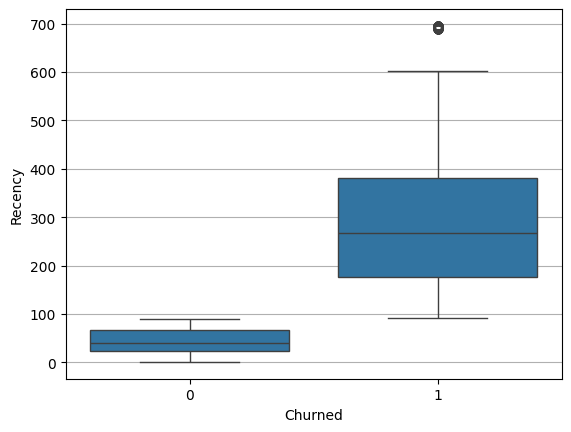

In [85]:
ax=sns.boxplot(data=churned_df, y='Recency', x='Churned')
plt.grid(axis='y')
plt.show()

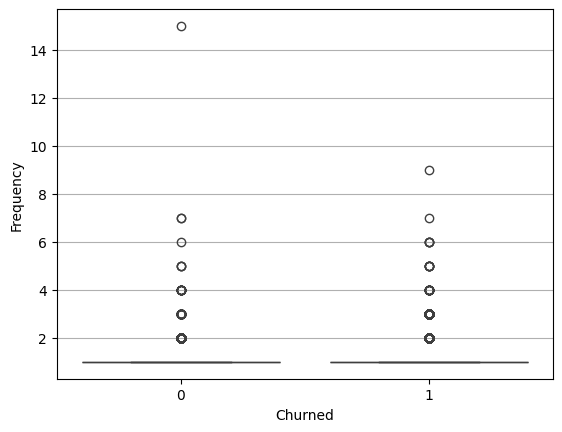

In [86]:
ax=sns.boxplot(data=churned_df, y='Frequency', x='Churned')
plt.grid(axis='y')
plt.show()

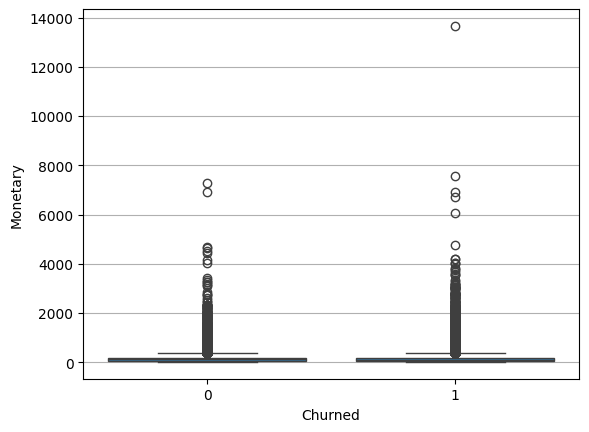

In [87]:
ax=sns.boxplot(data=churned_df, y='Monetary', x='Churned')
plt.grid(axis='y')
plt.show()

In [88]:
segment_churn=churned_df.groupby('Segment')['Churned'].mean()*100
print(segment_churn)
print(pd.DataFrame(segment_churn.sort_values(ascending=False)).rank(method="dense",numeric_only=True))

Segment
At Risk            100.000000
Big_Spenders        66.847347
Champions           51.724138
Hibernating        100.000000
Loyal Customers     66.975309
New Customers       67.237394
Name: Churned, dtype: float64
                 Churned
Segment                 
At Risk              5.0
Hibernating          5.0
New Customers        4.0
Loyal Customers      3.0
Big_Spenders         2.0
Champions            1.0


In [89]:
freq_churn_bucket=pd.DataFrame(churned_df.groupby('Frequency')['Churned'].mean()*100)
freq_churn_bucket.rename({'Churned':'churn_rate'})
freq_churn_bucket['Churned'] = round(freq_churn_bucket['Churned'],2)
# freq_churn_bucket=churned_df.groupby('Frequency')['Churned'].transform('mean')*100
# freq_churn_bucket

<Axes: xlabel='Frequency', ylabel='Churned'>

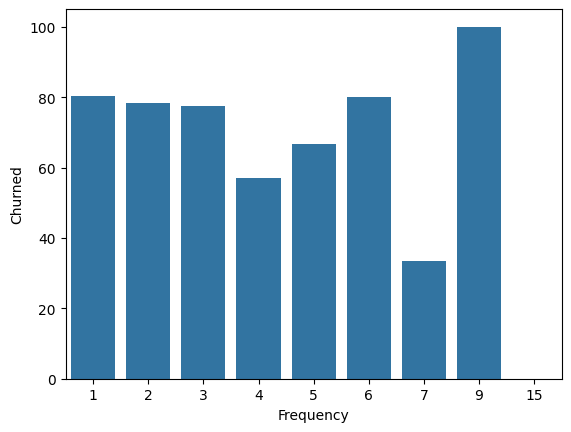

In [90]:
sns.barplot(data = freq_churn_bucket, x='Frequency', y='Churned')

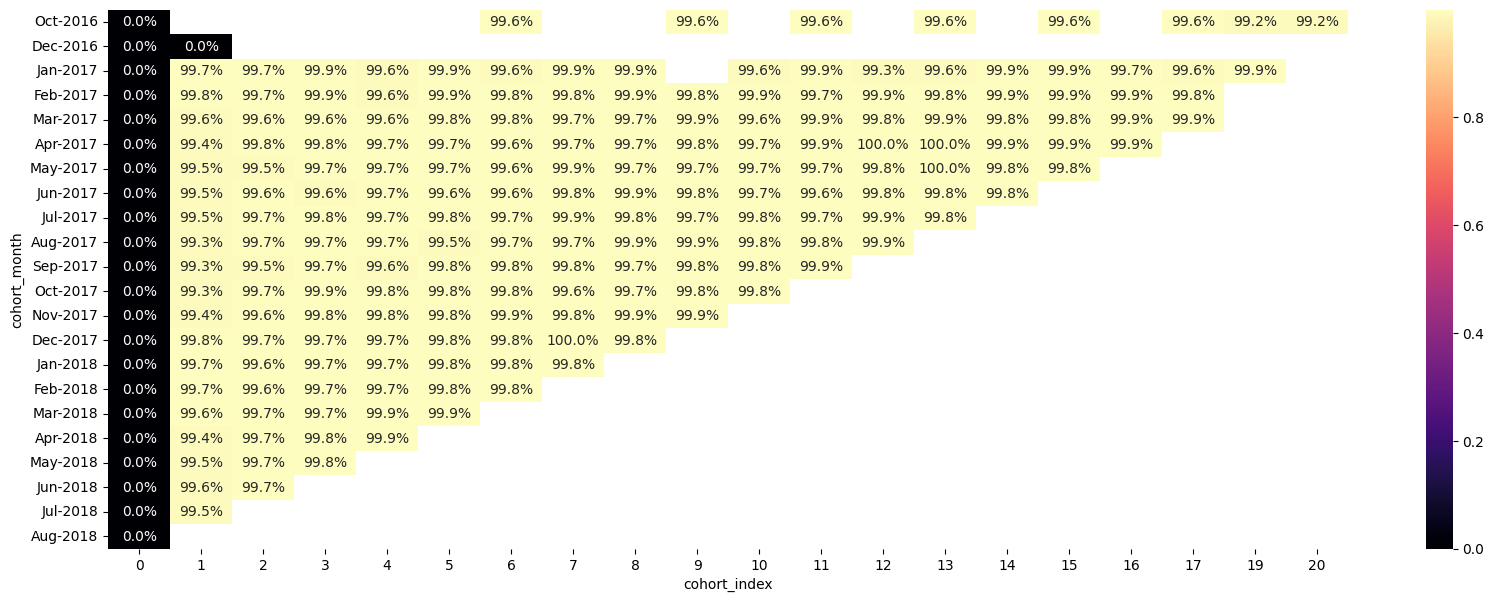

In [101]:
cohort.head(2)
cohort_matrix.head(2)
cohort_churn_matrix = 1- cohort_matrix.iloc[:,:]
# cohort_churn_matrix = pd.concat([cohort_matrix.iloc[:,0] ,1- cohort_matrix.iloc[:,:]], axis=1)
plt.figure(figsize=(20,7))
sns.heatmap(cohort_churn_matrix, annot = True, cmap ="magma", fmt = ".1%" )
plt.show()

In [105]:
cohort.groupby('order_month')['customer_unique_id'].sum()

order_month
2016-10     262
2016-12       1
2017-01     718
2017-02    1630
2017-03    2508
2017-04    2274
2017-05    3479
2017-06    3076
2017-07    3802
2017-08    4114
2017-09    4083
2017-10    4417
2017-11    7183
2017-12    5450
2018-01    6974
2018-02    6400
2018-03    6914
2018-04    6744
2018-05    6693
2018-06    6061
2018-07    6100
2018-08    6310
Name: customer_unique_id, dtype: int64

In [ ]:
high_value_threshold = churned_df['Monetary'].quantile(0.75)
high_value_churners=churned_df[(churned_df['Monetary']>high_value_threshold) 
& (churned_df['Churned']==1)]

In [ ]:
high_value_churners[high_value_churners['Monetary']>180]

,cust_id,Recency,Frequency,Monetary,Segment,Churned
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,Hibernating,1
7,00053a61a98854899e70ed204dd4bafe,183,1,419.18,Big_Spenders,1
18,000de6019bb59f34c099a907c151d855,377,1,257.44,Hibernating,1
23,0010a452c6d13139e50b57f19f52e04e,415,1,325.93,Hibernating,1
25,001147e649a7b1afd577e873841632dd,363,1,212.16,Hibernating,1
...,...,...,...,...,...,...
93330,ffebb6424578e7bb153322da9d65634f,591,1,665.70,Hibernating,1
93334,ffeddf8aa7cdecf403e77b2e9a99e2ea,108,1,204.20,Big_Spenders,1
93342,fff2ae16b99c6f3c785f0e052f2a9cfb,132,1,200.90,Big_Spenders,1
93347,fff7219c86179ca6441b8f37823ba3d3,245,1,265.80,Big_Spenders,1


In [ ]:
churned_df.loc[churned_df['Monetary']<180, ['cust_id','Recency','Monetary']]

,cust_id,Recency,Monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,112,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,27.19
2,0000f46a3911fa3c0805444483337064,537,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,321,43.62
5,0004bd2a26a76fe21f786e4fbd80607f,146,166.98
...,...,...,...
93351,fffbf87b7a1a6fa8b03f081c5f51a201,245,167.32
93353,fffea47cd6d3cc0a88bd621562a9d061,262,84.58
93354,ffff371b4d645b6ecea244b27531430a,568,112.46
93355,ffff5962728ec6157033ef9805bacc48,119,133.69
